# Exploratory Data Analysis — Electronics Pricing

## Objective

The purpose of this analysis is to understand pricing patterns, competitive positioning, merchant coverage, promotional activity, product conditions, shipping practices, and category-level competition in the electronics market.

### Business Questions

1. How do prices differ across product categories and brands?
2. Which brands are positioned as premium or budget brands?
3. How frequently are products listed as being on sale?
4. Which merchants have the strongest product and brand coverage?
5. How does product condition affect price?
6. How does shipping availability differ across merchants and categories?
7. Which product categories appear most competitive?
8. Where may there be opportunities for competitive pricing or market positioning?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/electronics_pricing_clean.csv"
)

print("Shape:", df.shape)
df.head()

column_audit = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique()
})

column_audit

Shape: (7235, 33)


,dtype,missing,missing_pct,unique
id,str,0,0.00,835
prices.amountMax,float64,0,0.00,2515
prices.amountMin,float64,0,0.00,2664
prices.availability,str,0,0.00,14
prices.condition,str,0,0.00,11
prices.currency,str,0,0.00,1
prices.dateSeen,str,0,0.00,3828
prices.isSale,bool,0,0.00,2
prices.merchant,str,0,0.00,692
prices.shipping,str,2962,40.94,73


What does the overall price distribution look like?

In [2]:
df["price"].describe()
print("Median price:", df["price"].median())
print("Mean price:", df["price"].mean())
print("25th percentile:", df["price"].quantile(0.25))
print("75th percentile:", df["price"].quantile(0.75))

Median price: 196.765
Mean price: 480.667190739461
25th percentile: 79.99
75th percentile: 488.745


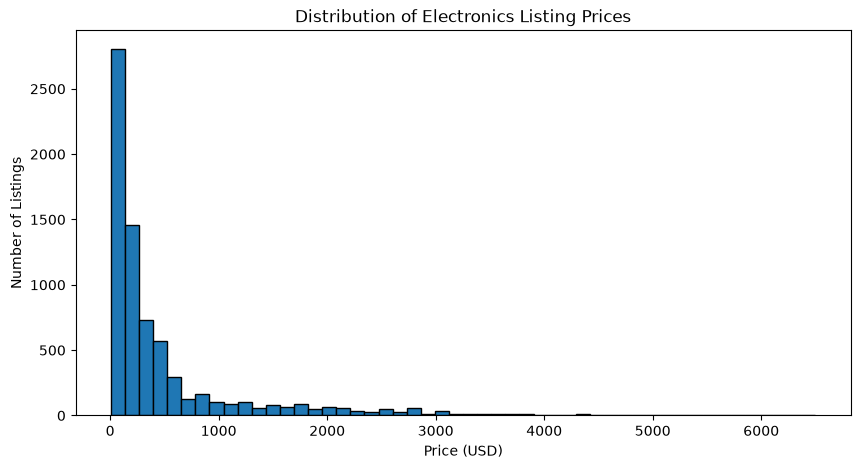

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=50, edgecolor="black")

plt.title("Distribution of Electronics Listing Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

plt.show()

### Price Distribution Insight

The distribution of listing prices is strongly right-skewed. Most electronics
listings are concentrated in the lower price range, while a smaller number of
premium products extend the distribution to approximately $6,500.

The mean listing price ($480.67) is substantially higher than the median
($196.77), indicating that high-priced products pull the average upward.
The middle 50% of listings are priced between approximately $79.99 and $488.75.

Because of this skewness, the median provides a more representative measure
of a typical listing price than the mean. High-priced observations were
previously investigated and retained because they represented plausible
premium electronics rather than obvious data errors.

# How do prices differ across product categories?

In [4]:
category_price = (
    df.groupby("category_clean")["price"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
)

category_price

,count,mean,median
category_clean,,,
TV & Home Theater,1913,937.82,454.95
Cameras & Photography,881,401.86,213.37
Computers & Tablets,2199,421.75,179.99
Audio,299,174.50,129.99
Automotive Electronics,796,167.38,102.98
Mobile & Phones,1145,189.22,99.99
Other Electronics,2,26.50,26.50


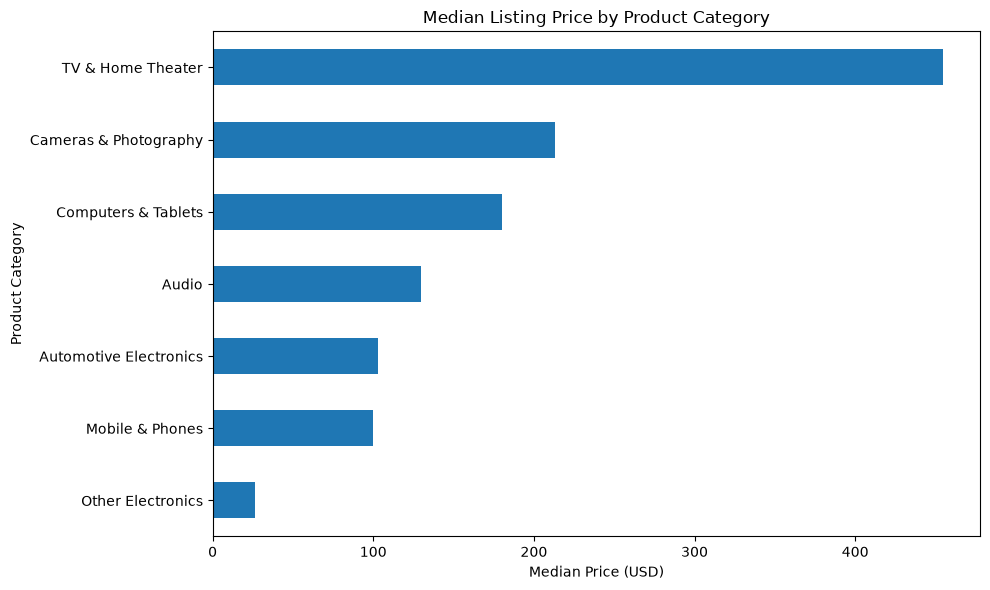

In [5]:
category_median = (
    df.groupby("category_clean")["price"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

category_median.plot(kind="barh")

plt.title("Median Listing Price by Product Category")
plt.xlabel("Median Price (USD)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Category Pricing Insight

TV & Home Theater has the highest median listing price at approximately
$454.95, substantially higher than all other product categories. Cameras &
Photography follows at $213.37, while Computers & Tablets has a median price
of $179.99.

Mobile & Phones and Automotive Electronics have considerably lower median
listing prices, at approximately $99.99 and $102.98 respectively.

These results suggest that the dataset contains substantially different price
segments across product categories. Therefore, overall market averages should
not be used to compare products across categories; pricing comparisons should
primarily be made within the same product category.

The Other Electronics category is not interpreted because it contains only
two listings.

In [6]:
brand_summary = (
    df.groupby("brand_clean")
    .agg(
        listings=("price", "count"),
        products=("id", "nunique"),
        median_price=("price", "median")
    )
    .sort_values("listings", ascending=False)
)

brand_summary.head(20)

,listings,products,median_price
brand_clean,,,
Sony,785,63,488.0000
Samsung,743,50,479.9900
Apple,243,20,1349.2000
Yamaha,240,41,279.9900
Corsair,195,24,139.9900
Pioneer,176,14,159.7375
Lg,175,9,2197.0000
Western Digital,159,12,199.9900
Sandisk,138,13,146.5000


In [7]:
brand_category = pd.crosstab(
    df["brand_clean"],
    df["category_clean"]
)
brand_category.head(20)
#brand_category.loc[
    #brand_summary.head(10).index
#]
computer_data = df[df["category_clean"] == "Computers & Tablets"]
computer_data.shape
computer_groups = computer_data.groupby("brand_clean")
#computer_groups.size().sort_values(ascending=False)
#computer_groups.size().sort_values(ascending=False)
#computer_groups["id"].nunique().sort_values(ascending=False)
#computer_groups["price"].median().sort_values(ascending=False)
#computer_data[computer_data["brand_clean"] == "Intel"]["id"].nunique()
#computer_data[computer_data["brand_clean"] == "Apple"]["id"].nunique()

computer_listings = computer_groups.size()
computer_products = computer_groups["id"].nunique()
computer_median_price = computer_groups["price"].median()
computer_summary = pd.DataFrame()
computer_summary["listings"] = computer_listings
computer_summary["products"] = computer_products
computer_summary["median_price"] = computer_median_price
computer_summary.head(30)
#computer_summary["products"] >= 5
computer_summary["products"].value_counts().sort_index() # how many brands have 1 product, 2 products, etc.

products
1     45
2     16
3      7
4      3
5      3
7      2
9      3
11     2
12     1
14     1
22     1
Name: count, dtype: int64

# So comparing all 85 brands by median price would be unreliable. A brand with one expensive product could appear to be the “most premium,” like we saw with Intel.

For this project, using at least 5 unique products is a reasonable practical rule for the brand-positioning comparison. We should document that this is an analysis threshold, not a universal statistical rule.

In [8]:
reliable_computer_brands = computer_summary[
    computer_summary["products"] >= 5
]
reliable_computer_brands

,listings,products,median_price
brand_clean,,,
Apple,164,14,1695.990
Asus,113,7,329.000
Corsair,185,22,143.680
Lenovo,110,9,297.495
Logitech,57,9,74.950
Netgear,82,11,129.990
Pny,31,5,79.990
Razer,59,5,170.990
Samsung,124,12,246.970


### IMPORTANT

Apple: 164 listings, 14 products, median $1,695.99
WD: 87 listings, 6 products, median $455.90
ASUS: 113 listings, 7 products, median $329.00
TP-Link: 58 listings, 5 products, median $39.94

But there's another important issue hiding here: Wd and Western Digital are probably the same brand represented under two names. We shouldn't silently merge them yet, but we should flag this as a brand-cleaning limitation.

In [9]:
reliable_computer_brands.sort_values(
    "median_price",
    ascending=False
)

,listings,products,median_price
brand_clean,,,
Apple,164,14,1695.990
Western Digital,138,11,329.990
Asus,113,7,329.000
Lenovo,110,9,297.495
Yamaha,62,9,279.990
Samsung,124,12,246.970
Sandisk,80,7,199.370
Razer,59,5,170.990
Corsair,185,22,143.680


# one data-quality issue we just discovered
Wd                 $455.90
Western Digital    $290.00
# These appear to represent the same brand, Western Digital, under different labels. If we leave them separate, our brand analysis could be distorted
Solved 

In [10]:
df[df["brand_clean"].isin(["Wd", "Western Digital"])][
    ["brand", "brand_clean", "name"]
].drop_duplicates()

,brand,brand_clean,name
66,WD,Western Digital,2TB Red 5400 rpm SATA III 3.5 Internal NAS HDD
269,WD,Western Digital,4TB Red 5400 rpm SATA III 3.5 Internal NAS HDD...
541,WD,Western Digital,WD - My Passport X 3TB External USB 3.0 Portab...
1164,WD,Western Digital,WD - Se 2TB Internal Serial ATA Hard Drive for...
1857,WD,Western Digital,My Cloud Expert Series EX4100 24TB 4-Bay NAS S...
2852,WD,Western Digital,1TB WD Black Mobile OEM Hard Drive (WD10JPLX)
3505,Western Digital,Western Digital,WD 4TB My Cloud Home Personal Cloud Storage - ...
3694,WD,Western Digital,"4TB Network OEM HDD Retail Kit (8-Pack, WD40EF..."
4032,Western Digital,Western Digital,Details About Wd Red Pro 8tb Nas Desktop Hard ...
4618,Western Digital,Western Digital,WD - My Book 6TB External USB 3.0 Hard Drive -...


In [11]:
computer_data = df[df["category_clean"] == "Computers & Tablets"]

computer_groups = computer_data.groupby("brand_clean")

computer_summary = pd.DataFrame({
    "listings": computer_groups.size(),
    "products": computer_groups["id"].nunique(),
    "median_price": computer_groups["price"].median()
})
computer_summary.shape

reliable_computer_brands = computer_summary[
    computer_summary["products"] >= 5
]

reliable_computer_brands.sort_values(
    "median_price",
    ascending=False
)


,listings,products,median_price
brand_clean,,,
Apple,164,14,1695.990
Western Digital,138,11,329.990
Asus,113,7,329.000
Lenovo,110,9,297.495
Yamaha,62,9,279.990
Samsung,124,12,246.970
Sandisk,80,7,199.370
Razer,59,5,170.990
Corsair,185,22,143.680


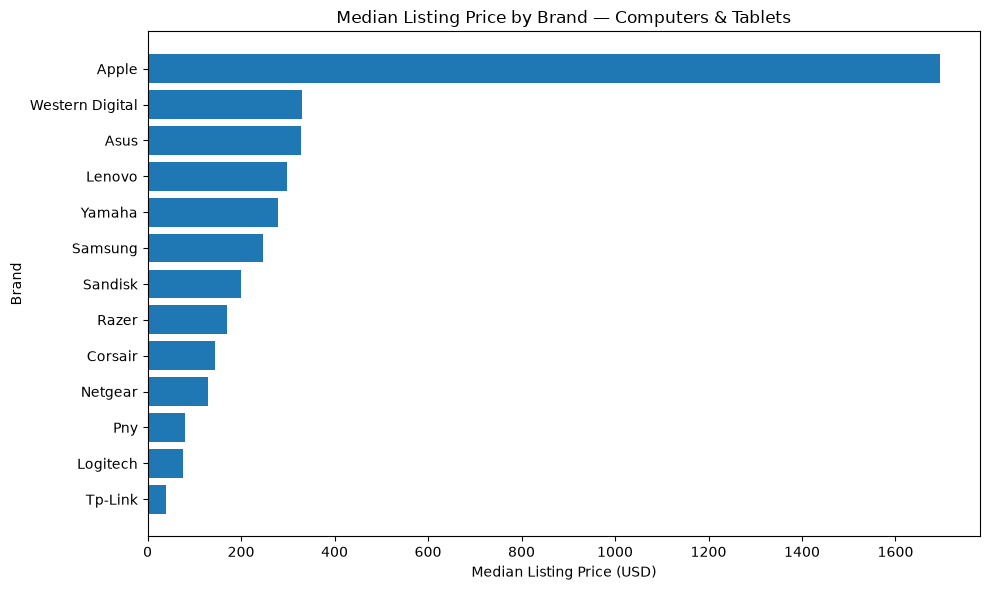

In [12]:
brand_price_plot = reliable_computer_brands.sort_values(
    "median_price"
)

plt.figure(figsize=(10, 6))

plt.barh(
    brand_price_plot.index,
    brand_price_plot["median_price"]
)

plt.title("Median Listing Price by Brand — Computers & Tablets")
plt.xlabel("Median Listing Price (USD)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

### Brand Pricing Insight — Computers & Tablets

Among brands represented by at least five unique products, Apple has the
highest median listing price at approximately $1,696, substantially above
the other brands in the Computers & Tablets category.

Western Digital and Asus have median listing prices of approximately $330,
followed by Lenovo at approximately $297 and Yamaha at $280. At the lower
end of this comparison, TP-Link, Logitech, and PNY have substantially lower
median listing prices.

However, these results should not be interpreted as direct evidence that one
brand is universally more premium or more affordable than another. The
Computers & Tablets category contains different types of products, including
computers, storage devices, networking equipment, and accessories. Differences
in product mix can therefore strongly influence each brand's median price.

A minimum threshold of five unique products per brand was used to reduce the
influence of brands represented by only one or a few products. This threshold
is a practical descriptive filter rather than a statistical significance rule.

## Sale and Promotion Analysis
How dependent are electronics listings on sales/promotions?

In [13]:
df["prices.isSale"].value_counts()

prices.isSale
False    5504
True     1731
Name: count, dtype: int64

# Now we want the sale rate (%), which is much more useful as a KPI.

In [14]:
sale_rate = df["prices.isSale"].mean() * 100

print(f"Sale rate: {sale_rate:.2f}%")

Sale rate: 23.93%


In [15]:
#Sale rate by category

category_sale_rate = (
    df.groupby("category_clean")["prices.isSale"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

category_sale_rate

category_clean
TV & Home Theater         32.723471
Cameras & Photography     24.517594
Automotive Electronics    21.356784
Computers & Tablets       20.372897
Mobile & Phones           19.126638
Audio                     17.391304
Other Electronics          0.000000
Name: prices.isSale, dtype: float64

# I first calculated the overall sale rate, which was 23.93%. Then I grouped the listings by product category and calculated the sale rate separately for each category. This allows us to see which categories have higher or lower promotional activity compared with the overall dataset.
The overall sale rate is 23.93%, meaning roughly one in four listings is marked as being on sale. However, promotional activity differs across categories. TV & Home Theater has the highest sale rate at 32.72%, while Audio has the lowest among the major categories at 17.39%. This suggests that sale-marked listings are more prevalent in TV & Home Theater than in the other major categories in this dataset.

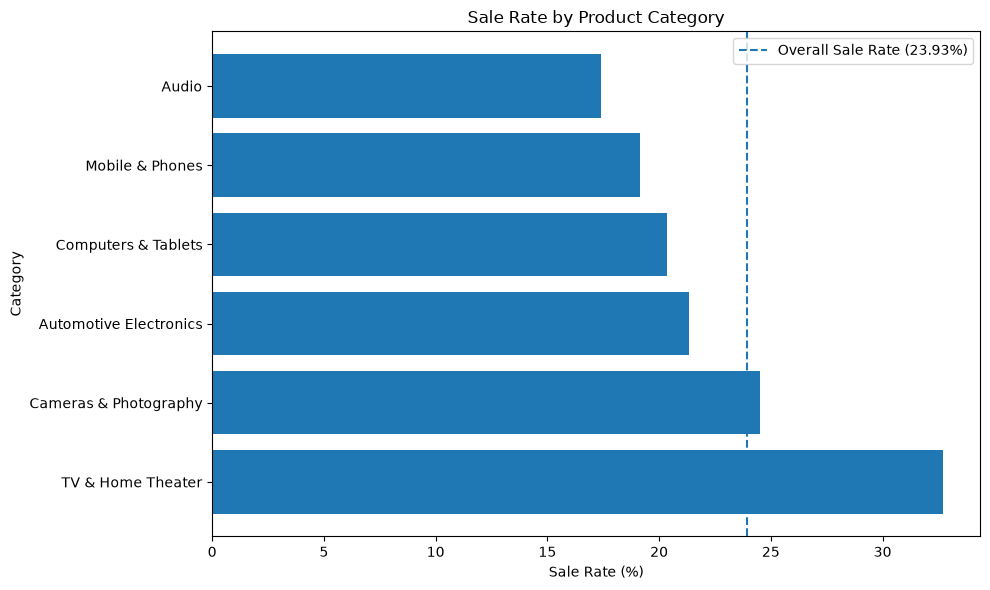

In [39]:
category_sale_plot = category_sale_rate.drop("Other Electronics")

plt.figure(figsize=(10, 6))

plt.barh(
    category_sale_plot.index,
    category_sale_plot.values
)

plt.axvline(
    sale_rate,
    linestyle="--",
    label=f"Overall Sale Rate ({sale_rate:.2f}%)"
)

plt.xlabel("Sale Rate (%)")
plt.ylabel("Category")
plt.title("Sale Rate by Product Category")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
computer_sale = (
    df[df["category_clean"] == "Computers & Tablets"]
    .groupby("brand_clean")
    .agg(
        listings=("id", "size"),
        products=("id", "nunique"),
        sale_rate=("prices.isSale", "mean")
    )
)

computer_sale["sale_rate"] = computer_sale["sale_rate"] * 100

computer_sale.head()

,listings,products,sale_rate
brand_clean,,,
Acer,30,4,26.666667
Actiontec,33,1,27.272727
Alienware,60,3,36.666667
Antec,5,1,0.000000
Aoc,30,2,20.000000


In [41]:
reliable_computer_sale = computer_sale[
    computer_sale["products"] >= 5
].sort_values("sale_rate", ascending=False)

reliable_computer_sale

,listings,products,sale_rate
brand_clean,,,
Razer,59,5,35.593220
Apple,164,14,34.146341
Sandisk,80,7,33.750000
Lenovo,110,9,32.727273
Asus,113,7,22.123894
Yamaha,62,9,19.354839
Samsung,124,12,16.935484
Corsair,185,22,14.054054
Tp-Link,58,5,13.793103


### Interpretation

Among Computers & Tablets brands with at least five unique products, sale-marked
listing rates vary substantially. Razer, Apple, SanDisk, and Lenovo show sale rates
above 32%, compared with the overall category sale rate of 20.37%. In contrast,
Western Digital and PNY have sale rates below 10%.

These results describe the frequency with which listings are marked as being on sale;
they do not measure discount size, sales volume, revenue impact, or dependence on
promotions. Brands near the five-product inclusion threshold should also be interpreted
with additional caution.

Where are these products being sold, and are a few merchants dominating the listings?

In [42]:
merchant_summary = (
    df.groupby("merchant_clean")
      .agg(
          listings=("id", "size"),
          products=("id", "nunique")
      )
      .sort_values("listings", ascending=False)
)

merchant_summary.head(10)

,listings,products
merchant_clean,,
bestbuy.com,2794,815
bhphotovideo.com,1509,492
walmart.com,663,233
beach camera,201,71
ami ventures inc,63,46
buydig,53,31
focus camera,48,24
gear4less,43,8
echo-and-optics,40,13


In [43]:
merchant_summary["listing_share"] = (
    merchant_summary["listings"] / len(df) * 100
)

merchant_summary.head(10)

,listings,products,listing_share
merchant_clean,,,
bestbuy.com,2794,815,38.617830
bhphotovideo.com,1509,492,20.856945
walmart.com,663,233,9.163787
beach camera,201,71,2.778162
ami ventures inc,63,46,0.870767
buydig,53,31,0.732550
focus camera,48,24,0.663442
gear4less,43,8,0.594333
echo-and-optics,40,13,0.552868


For each merchant, what percentage of all 7,235 listing records comes from that merchant?

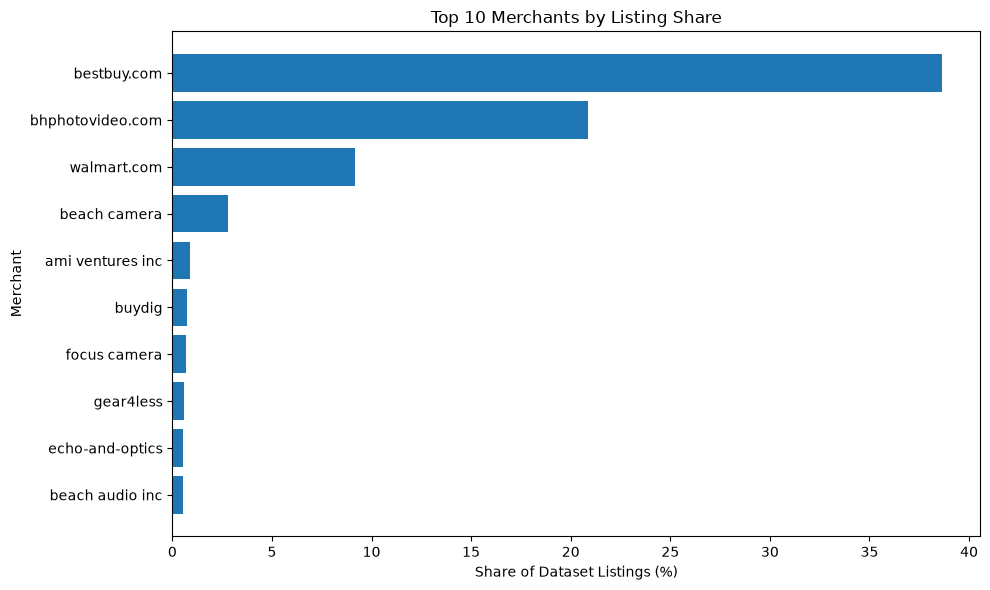

In [44]:
top_merchants = merchant_summary.head(10).sort_values("listing_share")

plt.figure(figsize=(10, 6))

plt.barh(
    top_merchants.index,
    top_merchants["listing_share"]
)

plt.xlabel("Share of Dataset Listings (%)")
plt.ylabel("Merchant")
plt.title("Top 10 Merchants by Listing Share")

plt.tight_layout()
plt.show()

Condition Analysis

In [45]:
condition_summary = (
    df.groupby("condition_clean")
      .agg(
          listings=("id", "size"),
          products=("id", "nunique"),
          median_price=("price", "median")
      )
      .sort_values("median_price", ascending=False)
)
condition_summary.head()

,listings,products,median_price
condition_clean,,,
new,7005,831,198.00
used,146,94,129.97
refurbished,83,45,107.99
other,1,1,70.68


In [46]:
product_condition_count = (
    df.groupby("id")["condition_clean"]
      .nunique()
)

product_condition_count.value_counts().sort_index()

condition_clean
1    715
2    104
3     16
Name: count, dtype: int64

In [47]:
condition_combinations = (
    df.groupby("id")["condition_clean"]
      .apply(lambda x: tuple(sorted(x.unique())))
      .value_counts()
)

condition_combinations

condition_clean
(new,)                      714
(new, used)                  75
(new, refurbished)           25
(new, refurbished, used)     16
(refurbished, used)           3
(refurbished,)                1
(new, other)                  1
Name: count, dtype: int64

In [48]:
new_used = (
    df[df["condition_clean"].isin(["new", "used"])]
    .groupby(["id", "condition_clean"])["price"]
    .median()
    .unstack()
    .dropna()
)

new_used.head()

condition_clean,new,used
id,,
AV03XQcRglJLPUi8HuMv,799.99,699.95
AV1YDIi6vKc47QAVgpcL,451.99,389.97
AV1YDT2uvKc47QAVgpgi,798.00,600.00
AV1YDsmoGV-KLJ3adcbe,549.99,449.95
AV1YF-rE-jtxr-f31NQi,118.36,96.99


In [49]:
new_used["savings_pct"] = (
    (new_used["new"] - new_used["used"])
    / new_used["new"]
    * 100
)

new_used.head()

condition_clean,new,used,savings_pct
id,,,
AV03XQcRglJLPUi8HuMv,799.99,699.95,12.505156
AV1YDIi6vKc47QAVgpcL,451.99,389.97,13.721543
AV1YDT2uvKc47QAVgpgi,798.00,600.00,24.812030
AV1YDsmoGV-KLJ3adcbe,549.99,449.95,18.189422
AV1YF-rE-jtxr-f31NQi,118.36,96.99,18.055086


In [50]:
print("Products compared:", len(new_used))
print("Median savings:", new_used["savings_pct"].median())
print("Average savings:", new_used["savings_pct"].mean())

Products compared: 91
Median savings: 31.45792489247557
Average savings: 33.086927099778585


In [51]:
(new_used["savings_pct"] < 0).sum()

np.int64(4)

In [52]:
new_refurb = (
    df[df["condition_clean"].isin(["new", "refurbished"])]
    .groupby(["id", "condition_clean"])["price"]
    .median()
    .unstack()
    .dropna()
)

new_refurb["savings_pct"] = (
    (new_refurb["new"] - new_refurb["refurbished"])
    / new_refurb["new"]
    * 100
)

print("Products compared:", len(new_refurb))
print("Median savings:", new_refurb["savings_pct"].median())
print("Average savings:", new_refurb["savings_pct"].mean())

Products compared: 41
Median savings: 35.01350135013501
Average savings: 34.05243569637831


In [53]:
(new_refurb["savings_pct"] < 0).sum()

np.int64(1)

Same-product comparisons show substantial price differences by condition. Across 91 products listed as both new and used, used listings had a median price approximately 31.5% lower than new listings. Across 41 products available as both new and refurbished, refurbished listings were approximately 35.0% lower. Only a small number of matched products showed used or refurbished median prices above new prices.

"shipping_Analysis

In [54]:
df["shipping_type"].value_counts(dropna=False)

shipping_type
unknown             2962
paid/other          1929
conditional free    1477
free                 867
Name: count, dtype: int64

In [55]:
shipping_share = (
    df["shipping_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

shipping_share

shipping_type
unknown             40.94
paid/other          26.66
conditional free    20.41
free                11.98
Name: proportion, dtype: float64

Shipping information is incomplete for 40.94% of listings. Among the full dataset, 11.98% explicitly indicate free shipping and 20.41% indicate conditional free shipping; therefore, shipping-related conclusions should be interpreted cautiously.

In [56]:
shipping_by_category = pd.crosstab(
    df["category_clean"],
    df["shipping_type"],
    normalize="index"
) * 100

shipping_by_category.round(2)

shipping_type,conditional free,free,paid/other,unknown
category_clean,,,,
Audio,1.67,0.00,32.44,65.89
Automotive Electronics,4.02,12.19,39.70,44.10
Cameras & Photography,34.17,13.51,20.77,31.56
Computers & Tablets,21.10,10.32,21.96,46.61
Mobile & Phones,26.72,9.43,24.19,39.65
Other Electronics,0.00,0.00,0.00,100.00
TV & Home Theater,19.29,16.52,29.95,34.24


In [57]:
A useful observation is that Audio has 65.89% unknown shipping information, so shipping conclusions for Audio are especially unreliable. TV & Home Theater has the highest explicitly free-shipping percentage in your table at 16.52%, but we still need to remember the missing/unknown information.

SyntaxError: invalid syntax (1401585248.py, line 1)

Availability analysis

In [ ]:
df["availability_clean"].value_counts()

availability_clean
available          6852
limited/pending     200
unavailable         143
unknown              40
Name: count, dtype: int64

In [ ]:
availability_share = (
    df["availability_clean"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

availability_share

availability_clean
available          94.71
limited/pending     2.76
unavailable         1.98
unknown             0.55
Name: proportion, dtype: float64

### KPI

In [58]:
total_listings = len(df)
unique_products = df["id"].nunique()
unique_brands = df["brand_clean"].nunique()
unique_merchants = df["merchant_clean"].nunique()
median_price = df["price"].median()
sale_rate = df["prices.isSale"].mean() * 100

print("Total Listings:", total_listings)
print("Unique Products:", unique_products)
print("Unique Brands:", unique_brands)
print("Unique Merchants:", unique_merchants)
print("Median Price:", round(median_price, 2))
print("Sale Rate:", round(sale_rate, 2), "%")

Total Listings: 7235
Unique Products: 835
Unique Brands: 237
Unique Merchants: 680
Median Price: 196.76
Sale Rate: 23.93 %


# Category KPI table

In [59]:
category_kpis = (
    df.groupby("category_clean")
    .agg(
        listings=("id", "size"),
        products=("id", "nunique"),
        brands=("brand_clean", "nunique"),
        median_price=("price", "median"),
        sale_rate=("prices.isSale", "mean")
    )
)

category_kpis["sale_rate"] = category_kpis["sale_rate"] * 100

category_kpis.round(2)

,listings,products,brands,median_price,sale_rate
category_clean,,,,,
Audio,299,58,36,129.99,17.39
Automotive Electronics,796,92,37,102.98,21.36
Cameras & Photography,881,87,37,213.37,24.52
Computers & Tablets,2199,236,84,179.99,20.37
Mobile & Phones,1145,157,64,99.99,19.13
Other Electronics,2,1,1,26.50,0.00
TV & Home Theater,1913,204,57,454.95,32.72


For each category, how many listings, products and brands are there, what is its typical price, and how often are listings marked as on sale?

In [60]:
category_kpis["listing_share"] = (
    category_kpis["listings"] / total_listings * 100
)

category_kpis.round(2)

,listings,products,brands,median_price,sale_rate,listing_share
category_clean,,,,,,
Audio,299,58,36,129.99,17.39,4.13
Automotive Electronics,796,92,37,102.98,21.36,11.00
Cameras & Photography,881,87,37,213.37,24.52,12.18
Computers & Tablets,2199,236,84,179.99,20.37,30.39
Mobile & Phones,1145,157,64,99.99,19.13,15.83
Other Electronics,2,1,1,26.50,0.00,0.03
TV & Home Theater,1913,204,57,454.95,32.72,26.44


In [61]:
category_kpis.to_csv(
    "../data/processed/category_kpis.csv"
)

Create the overall KPI table

In [62]:
overall_kpis = pd.DataFrame({
    "metric": [
        "Total Listings",
        "Unique Products",
        "Unique Brands",
        "Unique Merchants",
        "Median Price",
        "Sale Rate (%)"
    ],
    "value": [
        total_listings,
        unique_products,
        unique_brands,
        unique_merchants,
        round(median_price, 2),
        round(sale_rate, 2)
    ]
})

overall_kpis

,metric,value
0,Total Listings,7235.00
1,Unique Products,835.00
2,Unique Brands,237.00
3,Unique Merchants,680.00
4,Median Price,196.76
5,Sale Rate (%),23.93


In [63]:
overall_kpis.to_csv(
    "../data/processed/overall_kpis.csv",
    index=False
)

business insight layer

In [65]:
#Create the condition KPI table
condition_kpis = pd.DataFrame({
    "comparison": [
        "Used vs New",
        "Refurbished vs New"
    ],
    "matched_products": [
        len(new_used),
        len(new_refurb)
    ],
    "median_savings_pct": [
        new_used["savings_pct"].median(),
        new_refurb["savings_pct"].median()
    ]
})

condition_kpis.round(2)

,comparison,matched_products,median_savings_pct
0,Used vs New,91,31.46
1,Refurbished vs New,41,35.01


In [ ]:
condition_kpis.to_csv(
    "../data/processed/condition_kpis.csv",
    index=False
)

merchant concentration KPI

In [66]:
top_3_merchant_share = (
    merchant_summary.head(3)["listings"].sum()
    / total_listings
    * 100
)

round(top_3_merchant_share, 2)

np.float64(68.64)

68.64% of all listing records come from the top three merchants.

Important: this means the dataset is concentrated around those merchants. It does not mean those merchants have 68.64% real-world market share.

In [67]:
merchant_kpis = pd.DataFrame({
    "metric": ["Top 3 Merchant Listing Share (%)"],
    "value": [round(top_3_merchant_share, 2)]
})

merchant_kpis.to_csv(
    "../data/processed/merchant_kpis.csv",
    index=False
)

merchant_kpis

,metric,value
0,Top 3 Merchant Listing Share (%),68.64
